## Classification Model

In [1]:
print('This Notebook only for classification research!!')

This Notebook only for classification research!!


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [4]:
df=pd.read_csv(r'E:\dsProject\customerSegmentation\data\clean_Customer_RetailNw4.csv')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSum,hours,weeks,month,year,Recency,Frequency,MonetaryValue,ClusterLabel
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,7,Tuesday,December(2009),2009,314,6,2017.2,Hibernating / Risk of Churn
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,Tuesday,December(2009),2009,314,6,2017.2,Hibernating / Risk of Churn
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,Tuesday,December(2009),2009,314,6,2017.2,Hibernating / Risk of Churn
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,7,Tuesday,December(2009),2009,314,6,2017.2,Hibernating / Risk of Churn
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,7,Tuesday,December(2009),2009,314,6,2017.2,Hibernating / Risk of Churn


Data Importing

In [5]:
Df=df.drop_duplicates(subset='Customer ID')
ml_df=Df[['Recency','Frequency','MonetaryValue','ClusterLabel']].copy()
ml_df

,Recency,Frequency,MonetaryValue,ClusterLabel
0,314,6,2017.20,Hibernating / Risk of Churn
12,1,32,16904.51,Enterprise / VIP Whales
31,83,2,613.08,Hibernating / Risk of Churn
54,0,80,241958.05,Enterprise / VIP Whales
71,0,22,10665.69,Enterprise / VIP Whales
...,...,...,...,...
396135,1,1,168.60,New / Promising Customers
396366,1,1,590.00,New / Promising Customers
396881,0,1,258.75,New / Promising Customers
397148,0,1,258.28,New / Promising Customers


In [6]:
ml_df

,Recency,Frequency,MonetaryValue,ClusterLabel
0,314,6,2017.20,Hibernating / Risk of Churn
12,1,32,16904.51,Enterprise / VIP Whales
31,83,2,613.08,Hibernating / Risk of Churn
54,0,80,241958.05,Enterprise / VIP Whales
71,0,22,10665.69,Enterprise / VIP Whales
...,...,...,...,...
396135,1,1,168.60,New / Promising Customers
396366,1,1,590.00,New / Promising Customers
396881,0,1,258.75,New / Promising Customers
397148,0,1,258.28,New / Promising Customers


In [7]:
ml_df['ClusterLabel'].value_counts()

ClusterLabel
Champions/VIPs                 1232
Hibernating / Risk of Churn    1044
At-Risk / Lost Customers        975
New / Promising Customers       635
Enterprise / VIP Whales         254
Loyal Everyday Shoppers         131
Name: count, dtype: int64

Imbalanced Dataset

In [8]:
X=ml_df[['Recency','Frequency','MonetaryValue']].copy()
Y=ml_df['ClusterLabel'].copy()

Splitting Dataset  into Train & Test by stratified Sampling

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,Y,random_state=42,stratify=Y,test_size=0.2)

In [10]:
len(X)

4271

## Classification Model
DT,RF,XGB

* __Decision Tree__

In [46]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay,log_loss

In [47]:
model=DecisionTreeClassifier(criterion='gini',max_depth=5,min_samples_split=30,min_samples_leaf=15,class_weight='balanced',random_state=42)
model.fit(X_train,y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                       min_samples_leaf=15, min_samples_split=30,
                       random_state=42)

In [48]:
y_pred=model.predict(X_test)
y_prob=model.predict_proba(X_test)

In [63]:
print(f"=== DTC MODEL PERFORMANCE ON {len(X_test)} EVALUATION ROWS ===")
print(f"Overall Classification Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("=== PERFORMANCE PER SEGMENT ===")
print(classification_report(y_test, y_pred))
cm=confusion_matrix(y_test,y_pred)
print(f'Confusion Matrix : \n{cm} ')
print(f'Model Log loss: {log_loss(y_test,y_prob):.4f}')

=== DTC MODEL PERFORMANCE ON 855 EVALUATION ROWS ===
Overall Classification Accuracy: 96.14%

=== PERFORMANCE PER SEGMENT ===
                             precision    recall  f1-score   support

   At-Risk / Lost Customers       0.97      0.91      0.94       195
             Champions/VIPs       0.99      0.98      0.99       247
    Enterprise / VIP Whales       0.98      0.96      0.97        51
Hibernating / Risk of Churn       0.90      0.97      0.94       209
    Loyal Everyday Shoppers       0.89      0.96      0.93        26
  New / Promising Customers       1.00      0.98      0.99       127

                   accuracy                           0.96       855
                  macro avg       0.96      0.96      0.96       855
               weighted avg       0.96      0.96      0.96       855

Confusion Matrix : 
[[178   0   0  17   0   0]
 [  0 242   0   4   1   0]
 [  0   0  49   0   2   0]
 [  5   0   1 203   0   0]
 [  0   0   0   1  25   0]
 [  0   2   0   0   0 125]

* __Random Forest Classifier__

In [53]:
from sklearn.ensemble import RandomForestClassifier

rf_model=RandomForestClassifier(criterion='gini',n_estimators=100,max_depth=5,min_samples_split=30,min_samples_leaf=15,class_weight='balanced',random_state=42
                                # ,n_jobs=-1
                                )

In [58]:
rf_model.fit(X_train,y_train)
y_RfPred=rf_model.predict(X_test)
y_RfProb=rf_model.predict_proba(X_test)

In [59]:
print(f"=== RFC MODEL PERFORMANCE ON {len(X_test)} EVALUATION ROWS ===")
print(f"Overall Classification Accuracy: {accuracy_score(y_test, y_RfPred) * 100:.2f}%\n")
print("=== PERFORMANCE PER SEGMENT ===")
print(classification_report(y_test, y_RfPred))

cm=confusion_matrix(y_test,y_pred)
print(f'Confusion Matrix : \n{cm} ')
print(f'Model Log loss: {log_loss(y_test,y_RfProb):.4f}')

=== RFC MODEL PERFORMANCE ON 855 EVALUATION ROWS ===
Overall Classification Accuracy: 97.66%

=== PERFORMANCE PER SEGMENT ===
                             precision    recall  f1-score   support

   At-Risk / Lost Customers       0.97      0.96      0.97       195
             Champions/VIPs       1.00      0.98      0.99       247
    Enterprise / VIP Whales       0.98      0.98      0.98        51
Hibernating / Risk of Churn       0.95      0.97      0.96       209
    Loyal Everyday Shoppers       0.86      0.96      0.91        26
  New / Promising Customers       1.00      1.00      1.00       127

                   accuracy                           0.98       855
                  macro avg       0.96      0.98      0.97       855
               weighted avg       0.98      0.98      0.98       855

Confusion Matrix : 
[[178   0   0  17   0   0]
 [  0 242   0   4   1   0]
 [  0   0  49   0   2   0]
 [  5   0   1 203   0   0]
 [  0   0   0   1  25   0]
 [  0   2   0   0   0 125]

=== TOP PREDICTIVE FEATURES ===
Recency          0.406580
Frequency        0.302908
MonetaryValue    0.290512
dtype: float64


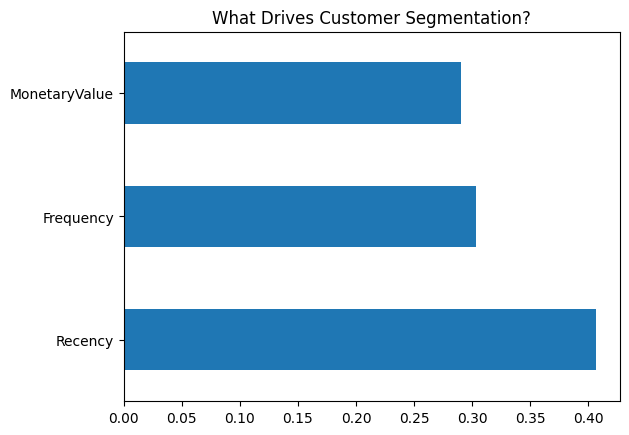

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importances from your trained RFC
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Create a clean DataFrame
feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print("=== TOP PREDICTIVE FEATURES ===")
print(feat_importances)

# Optional visual plot
feat_importances.head(10).plot(kind='barh')
plt.title('What Drives Customer Segmentation?')
plt.show()


### __Conclusion:__
__RFM__ is going to be selected with good *Log loss* value.It is robust, handles your small segments cleanly, and its aggregated probability scores are much safer for triggering automated marketing workflows.

* **Saving Model**

In [69]:
import joblib
import os
# 1. Define your specific folder location
output_dir = "../artifacts"
os.makedirs(output_dir, exist_ok=True)  # Creates folder if it does not exist

# 2. Build the full file path
file_path = os.path.join(output_dir, "RFCsegmentaion.joblib")
# 3. Saving the Scaler
joblib.dump(rf_model,file_path)

['../artifacts\\RFCsegmentaion.joblib']

In [67]:
%pwd

'e:\\dsProject\\customerSegmentation\\research'

In [64]:
model.predict([[45,14,3416]])

e:\dsProject\customerSegmentation\venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['Loyal Everyday Shoppers'], dtype=object)

In [2]:
%pip list

Package                   Version        Editable project locationNote: you may need to restart the kernel to use updated packages.

------------------------- -------------- ---------------------------------
altair                    6.2.2
annotated-doc             0.0.5
annotated-types           0.8.0
anyio                     4.14.2
argon2-cffi               23.1.0
argon2-cffi-bindings      21.2.0
arrow                     1.3.0
asttokens                 2.4.1
async-lru                 2.0.4
attrs                     24.2.0
babel                     2.16.0
beautifulsoup4            4.12.3
bleach                    6.1.0
blinker                   1.9.0
brotli                    1.2.0
certifi                   2024.7.4
cffi                      2.1.1
charset-normalizer        3.3.2
click                     8.4.2
colorama                  0.4.6
comm                      0.2.2
contourpy                 1.3.0
curl_cffi                 0.15.0
customerSegmentation      0.0.1          E:\ds